In [3]:
import pandas as pd
import numpy as np
import re
import sys
import subprocess
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
from scipy import stats

rcParams['font.family'] = 'Arial'

# Parameters

In [4]:
WORKDIR="update_numt_dataset/numtsV2"

## Utils

In [5]:
def sort_hsa(df_in):
    '''
    Sort HSA column in plotting order.
    '''
    df = df_in.copy()
    # Index for HSA.
    dict_hsa = {
        'hsa1':1, 'hsa2':2, 'hsa3':3, 'hsa4':4, 'hsa5':5, 'hsa6':6, 'hsa7':7, 'hsa8':8, 'hsa9':9, 'hsa10':10, 'hsa11':11, 'hsa12':12, 'hsa13':13, 'hsa14':14, 'hsa15':15, 'hsa16':16, 'hsa17':17, 'hsa18':18, 'hsa19':19, 'hsa20':20, 'hsa21':21, 'hsa22':22, 'hsa23':23, 'hsa24':24, 'hsaX':30, 'hsaY':31, 'hsa17x5':4, 'hsa5x17':19, 'hsa2a':2, 'hsa2b':2.5, 'hsa2A':2, 'hsa2B':2.5,
        'chr1':1, 'chr2':2, 'chr2A':2.3, 'chr2B':2.7, 'chr3':3, 'chr4':4, 'chr5':5, 'chr6':6, 'chr7':7, 'chr8':8, 'chr9':9, 'chr10':10, 'chr11':11, 'chr12':12, 'chr12_relab':12, 'chr13':13, 'chr14':14, 'chr15':15, 'chr16':16, 'chr17':17, 'chr18':18, 'chr19':19, 'chr19_relab':19, 'chr20':20, 'chr21':21, 'chr22':22, 'chr23':23, 'chr24':24, 'chrX':30, 'chrY':31
        }
    dict_hsa = {
        '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, 
        '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, 
        '15': 15, '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, 
        '21': 21, '22': 22, '23': 23, '24': 24, 'X': 30, 'Y': 31,
        '2A': 3, '2B': 3, '17x5': 28, '5x17': 29, '2a': 3, '2b': 3,
        '12_relab': 12, '19_relab': 19
        }

    df['index_HSA'] = df['HSA'].map(dict_hsa).fillna('MISSING')
    if df[df['index_HSA']=='MISSING'].shape[0] > 0:
        #return df[df['index_HSA']=='MISSING']
        df[df['index_HSA']=='MISSING']
        sys.exit(f'### Missing values in HSA column ###')
    return df.sort_values('index_HSA')


def relabel_siamang_chr(df):
    '''
    Assumes that the mislabeled chr 12 and chr 19 for Siamang have not been fixed upstream (May 8, 2024).
    Switches the labels for these chromosomes.
    '''
    # Change chr19 to chr12.
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr19'), 'Species_Chrom'] = 'chr12_relab'
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr12_relab'),'HSA'] = 'chr12_relab'

    #Change chr12 to chr19.
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr12'), 'Species_Chrom'] = 'chr19_relab'
    df.loc[(df['Species']=='Siamang')&(df['Species_Chrom']=='chr19_relab'),'HSA'] = 'chr19_relab'

    return df

dict_assembly_species = {
    'mGorGor1': 'Gorilla',
    'gorGor6': 'Gorilla',
    'mPanPan1': 'Bonobo',
    'panPan3': 'Bonobo',
    'mPanTro3': 'Chimpanzee',
    'panTro6': 'Chimpanzee',
    'mPonAbe1': 'Sumatran orangutan',  # Sumatran Orangutan
    'ponAbe3': 'Sumatran orangutan',   # Sumatran Orangutan
    'mPonPyg2': 'Bornean orangutan',  # Bornean Orangutan
    'mSymSyn1':'Siamang',
    'CHM13': 'Human',
    'GRCh38': 'Human'
}

colorblind_friendly_palette = {
    "Black": "#000000",
    "Orange": "#F4A637",
    "Light blue": "#B6DBFF",
    "Vermilion": "#DB5829",
    "Mid blue": "#7BB0DF",
    "Maroon": "#894B45",
    "Dark blue": "#1964B0",
    "Light purple": "#D2BBD7",
    "Light teal": "#00C992",
    "Purple": "#AE75A2",
    "Teal": "#008A69",
    "Dark purple": "#882D71",
    "Dark teal": "#386350",
    "Grey": "#DEDEDE",
    "Yellow": "#E9DC6D"
} # from Nature

palette7 = ["#005f73", "#0a9396", "#94d2bd", "#e9d8a6", "#ca6702", "#9b2226"] #subset of 6 colors from coolor.co palette of 10, colorblind tested in chroma.js

## Import NUMTs

In [6]:
assemblies=['mGorGor1', 'gorGor6', 'mPanPan1', 'panPan3', 'mPanTro3', 'panTro6', 'mPonAbe1', 'ponAbe3', 'mPonPyg2', 'CHM13', 'GRCh38', 'mSymSyn1']
t2t_assemblies = [ "mPanPan1", "mPanTro3", "CHM13", "mGorGor1", "mPonAbe1", "mPonPyg2", "mSymSyn1" ]

def get_numts():
    list_dfs=[]
    for assembly in t2t_assemblies:
        if assembly == 'CHM13':
            file_in = f"{WORKDIR}/numtsV2.{assembly}.noNC.bed" #NUMTs V2
        else:
            file_in = f"{WORKDIR}/numtsV2.{assembly}.bed" #NUMTs V2
        bed_headers = ['Chrom','Start','End','Name','Score','Strand']
        # Import BED file.
        df = pd.read_table( file_in, header=None, names=bed_headers )
        # Annotate.
        df['Assembly'] = assembly
        df['Species'] = df['Assembly'].map(dict_assembly_species)
        df['Species_Chrom'] = df['Chrom'].str.split('_').str[0]
        df['HSA'] = df['Chrom'].str.split('_').str[2].fillna(df['Species_Chrom'])
        #df.loc[ df['Assembly']=='mSymSyn1', 'HSA' ] = 'Does_not_apply' #Siamang does not have HSA
        df.loc[ df['Assembly']=='CHM13', 'HSA' ] = df['Chrom'] #Human has NC IDs
        df.loc[ df['Assembly']=='CHM13', 'Species_Chrom' ] = df['Chrom'] #Human has NC IDs
        df['Species_Chrom'] = df['Species_Chrom'].str.split('chr').str[-1]
        df['HSA'] = df['HSA'].str.split('hsa').str[-1].str.split('chr').str[-1]
        # Compute length of each NUMT.
        df['NUMT_Length'] = df['End'] - df['Start']
        list_dfs.append(df)
    df = pd.concat(list_dfs)
    return df#[['Assembly','HSA','Species_Chrom']].drop_duplicates()

numts = get_numts()
numts

,Chrom,Start,End,Name,Score,Strand,Assembly,Species,Species_Chrom,HSA,NUMT_Length
0,chr10_mat_hsa12,501,596,"NUMT_53bp,NUMT_93bp",V2.1,+,mPanPan1,Bonobo,10,12,95
1,chr10_mat_hsa12,13183007,13183147,NUMT_140bp_70%,V1.1,-,mPanPan1,Bonobo,10,12,140
2,chr10_mat_hsa12,13183379,13183661,NUMT_282bp_74%,V1.2,+,mPanPan1,Bonobo,10,12,282
3,chr10_mat_hsa12,13200452,13200702,NUMT_250bp_69%,V1.3,-,mPanPan1,Bonobo,10,12,250
4,chr10_mat_hsa12,13210027,13210127,NUMT_100bp_77%,V1.4,-,mPanPan1,Bonobo,10,12,100
...,...,...,...,...,...,...,...,...,...,...,...
630,chrX_hap1,146156531,146158069,NUMT_1538bp_71%,V1.606,+,mSymSyn1,Siamang,X,X,1538
631,chrX_hap1,146158433,146159056,NUMT_623bp_67%,V1.607,+,mSymSyn1,Siamang,X,X,623
632,chrX_hap1,146267555,146267607,NUMT_52bp_87%,V1.608,-,mSymSyn1,Siamang,X,X,52
633,chrY_hap2,7290606,7290724,NUMT_118bp_86%,V1.609,-,mSymSyn1,Siamang,Y,Y,118


In [7]:
def get_chrom_sizes():
    return pd.read_table( f"{WORKDIR}/all.chromSizes.noNC.txt", header=None, names=['Assembly','Chrom','Chrom_Size'] )

get_chrom_sizes()

,Assembly,Chrom,Chrom_Size
0,CHM13,chr1,248387328
1,CHM13,chr2,242696752
2,CHM13,chr3,201105948
3,CHM13,chr4,193574945
4,CHM13,chr5,182045439
...,...,...,...
179,mSymSyn1,chr22_hap1,80751072
180,mSymSyn1,chr23_hap1,78312223
181,mSymSyn1,chr24_hap1,79424044
182,mSymSyn1,chrX_hap1,165573899


## Compute NUMT abundance by chromosome

In [8]:
def compute_total_numt_bp_by_chr(df_in=False, excl_second_contigs=True, write=True):
    df = get_numts()
    df = df[['Species','Assembly','Chrom','Species_Chrom','HSA','Start','End']].drop_duplicates()
    # Exclude Y-chr.
    df = df[df['Species_Chrom']!='chrY']
    # Categorize assemblies.
    df['Version'] = 'non-T2T'
    df.loc[df['Assembly'].str[0]=='m','Version'] = 'T2T'
    df.loc[df['Assembly']=='CHM13','Version'] = 'T2T'
    # Length of each NUMT.
    df['Length'] = abs(df['End'] - df['Start'] + 1)
    # Counts of NUMTs by species.
    df_abundance = df.value_counts(['Species','Version','Assembly','Chrom','Species_Chrom','HSA']).reset_index().rename(columns={0:'NUMT_Counts','count':'NUMT_Counts'})
    # Sum of NUMT lengths.
    df_totalbp = df.groupby(['Species','Version','Assembly','Chrom','Species_Chrom','HSA'])['Length'].sum().reset_index().rename(columns={'Length':'Total_bp'})
    df = pd.merge( df_abundance, df_totalbp )
    # Numts as percentage of genome.
    df_chrom_sizes = get_chrom_sizes() #chrom sizes per species assembly.
    df = pd.merge( df, df_chrom_sizes )
    df = df.assign(Perc_chrom=100*df['Total_bp']/df['Chrom_Size']) #percentage of genome covered by NUMTs.
    df = df.sort_values(['Species_Chrom','Species'])
    # Normalize NUMT events and total NUMT length (bp) by chromosome size (bp).
    df['Density_of_bp'] = df['Total_bp'] / df['Chrom_Size']
    df['Density_of_events'] = df['NUMT_Counts'] / df['Chrom_Size']
    # # Switches labels for Siamang chr12 and chr19.
    # df = relabel_siamang_chr(df)
    # Export as table.
    if write == True:
        df.to_csv(f"{WORKDIR}/abundance_Numts_byChromosome.table", index=None, sep='\t')
    return df.drop_duplicates()
    

numts_summary = compute_total_numt_bp_by_chr()
numts_summary

,Species,Version,Assembly,Chrom,Species_Chrom,HSA,NUMT_Counts,Total_bp,Chrom_Size,Perc_chrom,Density_of_bp,Density_of_events
23,Bonobo,T2T,mPanPan1,chr1_pat_hsa1,1,1,50,73907,227705052,0.032457,0.000325,2.195823e-07
24,Bornean orangutan,T2T,mPonPyg2,chr1_hap1_hsa1,1,1,49,31597,230807400,0.013690,0.000137,2.122982e-07
21,Chimpanzee,T2T,mPanTro3,chr1_hap1_hsa1,1,1,50,32599,231299448,0.014094,0.000141,2.161700e-07
25,Gorilla,T2T,mGorGor1,chr1_pat_hsa1,1,1,49,48487,243847345,0.019884,0.000199,2.009454e-07
42,Human,T2T,CHM13,chr1,1,1,45,34604,248387328,0.013931,0.000139,1.811687e-07
...,...,...,...,...,...,...,...,...,...,...,...,...
41,Chimpanzee,T2T,mPanTro3,chrY_hap2_hsaY,Y,Y,45,98135,36447294,0.269252,0.002693,1.234660e-06
173,Gorilla,T2T,mGorGor1,chrY_pat_hsaY,Y,Y,5,470,67405748,0.000697,0.000007,7.417765e-08
156,Human,T2T,CHM13,chrY,Y,Y,12,9462,62460029,0.015149,0.000151,1.921229e-07
174,Siamang,T2T,mSymSyn1,chrY_hap2,Y,Y,2,253,29938336,0.000845,0.000008,6.680398e-08


## Scatter Plot of NUMT total length and Chom Sizes

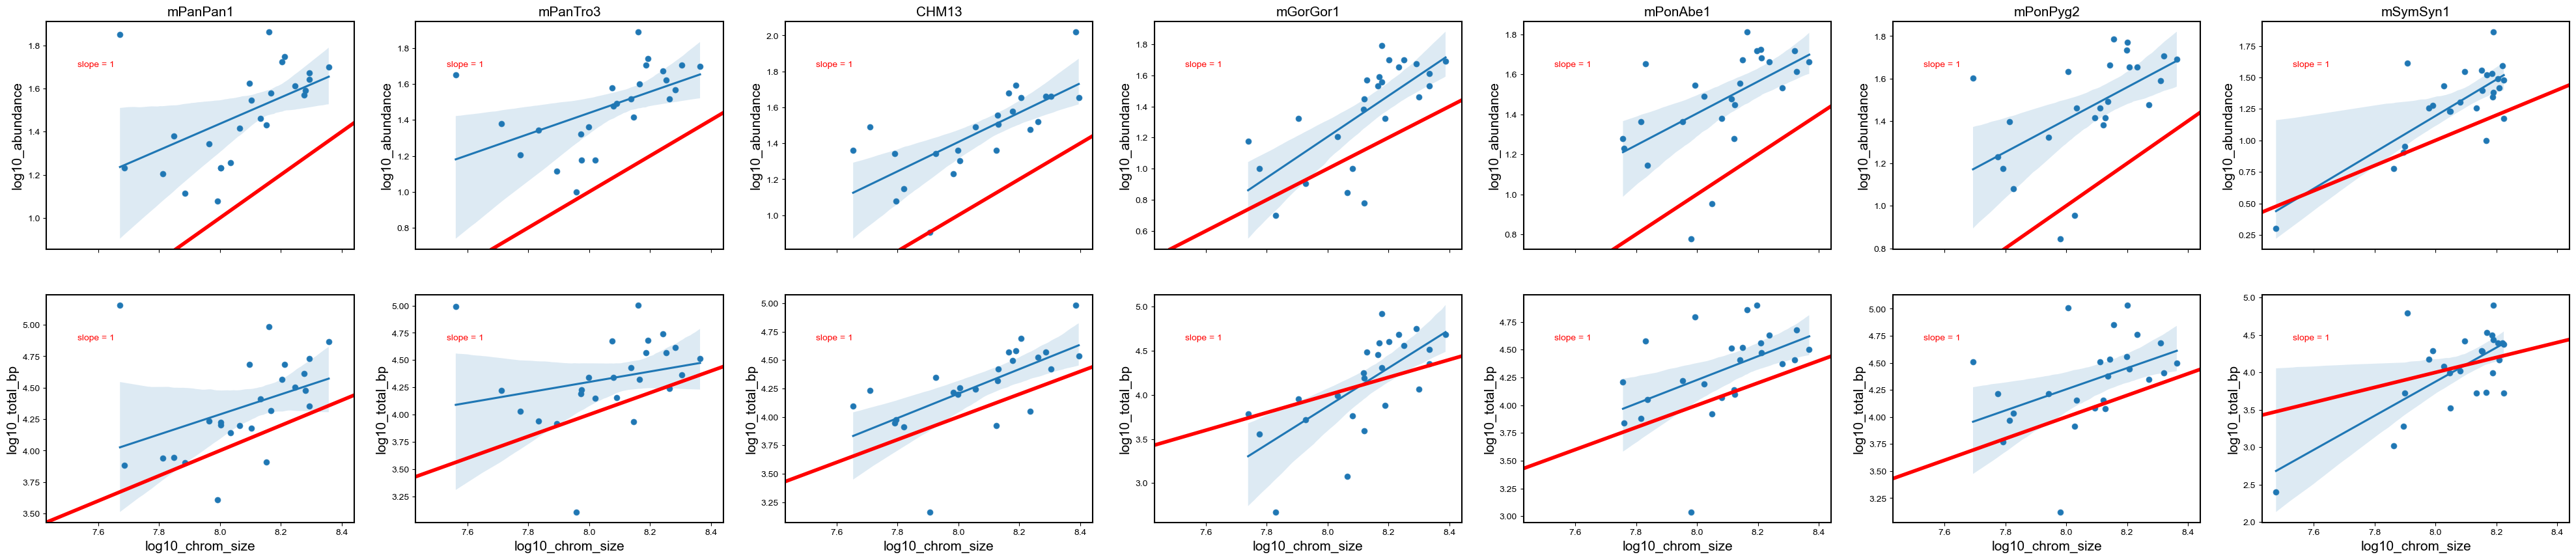

In [9]:
def plot_chrom_size( df_in, slope = 1 ):
    df = df_in.copy()
    df['log10_chrom_size'] = np.log10( df['Chrom_Size'] )
    df['log10_abundance'] = np.log10( df['NUMT_Counts'] )
    df['log10_total_bp'] = np.log10( df['Total_bp'] )
    list_assemblies = ['mPanPan1','mPanTro3','CHM13','mGorGor1','mPonAbe1','mPonPyg2','mSymSyn1']
    fig,axes = plt.subplots(2,len(list_assemblies), sharey=False, sharex=True, figsize=[50,10])
    for i,assembly in enumerate(list_assemblies):
        for j,metric in enumerate(['log10_abundance','log10_total_bp']):
            sns.scatterplot(
                data = df[df['Assembly']==assembly],
                x = 'log10_chrom_size',
                y = metric,
                ax = axes[j,i],
            )
            sns.regplot(
                data = df[df['Assembly']==assembly],
                x = 'log10_chrom_size',
                y = metric,
                ax = axes[j,i],
            )
            # Line with the approximate slope.
            intercept = {0:(8,1), 1:(8,4)}
            axes[j,i].axline( intercept[j] ,slope=slope, linewidth=4, color='r')
            plt.text(0.1,0.8,f"slope = {slope}", color='r', transform=axes[j,i].transAxes )
            # Annotate subplots.
            axes[0,i].set_title(f"{assembly}")
            #axes[0,i].set_xlabel(f"Chromosome size (bp)")
    #axes[0,0].set_ylabel(f"NUMT events")

plot_chrom_size(numts_summary)

In [10]:
numts_summary.groupby(['Species','Assembly'])['NUMT_Counts'].sum()

Species             Assembly
Bonobo              mPanPan1    864
Bornean orangutan   mPonPyg2    833
Chimpanzee          mPanTro3    846
Gorilla             mGorGor1    724
Human               CHM13       803
Siamang             mSymSyn1    635
Sumatran orangutan  mPonAbe1    843
Name: NUMT_Counts, dtype: int64

## Line/scatter-plot | NUMT stats by chromosome 

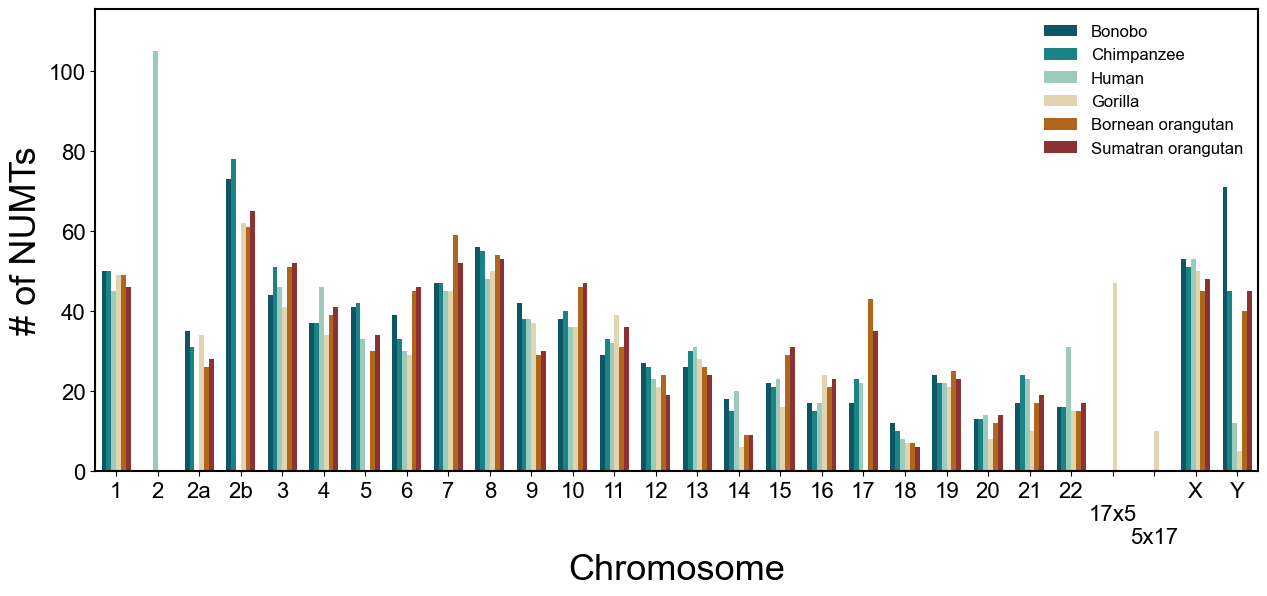

In [11]:
def plot_by_chr(df_in=numts_summary, y_column='Density_of_bp', kind='line'):
    df = df_in.copy()
    list_assemblies = ['mPanPan1','mPanTro3','CHM13','mGorGor1','mPonAbe1','mPonPyg2']
    df = df[df['Assembly'].isin(list_assemblies)]
    df = sort_hsa(df)
    # Change 17x5 and 5x17 labels to be lower in the plot.
    df = df.replace({'17x5':'\n17x5','5x17':'\n\n5x17'})
    # Seaborn parameters.
    rcParams['figure.figsize'] = 15,6
    # Plot.
    if y_column == 'NUMT_Counts':
        y_label = '# of NUMTs'
    elif y_column == 'Density_of_events':
        y_label = 'Density of total NUMT bp'
    elif y_column == 'Total_bp':
        y_label = 'Total NUMT length (kb)'
        df[y_column] = df[y_column]/1000
    elif y_column == 'Density_of_bp':
        y_label = 'Density of total NUMT bp'
    else:
        y_label = y_column
    species_order = ['Bonobo','Chimpanzee','Human','Gorilla','Bornean orangutan','Sumatran orangutan']
    # Palettes
    palette = [ colorblind_friendly_palette[x] for x in ['Dark blue', 'Light blue', 'Light teal', 'Purple', 'Yellow', 'Vermilion' ] ]
    #palette = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
    palette = palette7
    # Plot
    if kind == 'bar':
        sns.barplot(
            data = df.sort_values('index_HSA', ascending=True), x = 'HSA', y = y_column, hue = 'Species',
            hue_order = species_order,
            palette = palette, gap=0, width=0.7,
        )
    elif kind == 'line':
        sns.lineplot(
            data = df.sort_values('index_HSA', ascending=True), x = 'HSA', y = y_column, hue = 'Species', hue_order = species_order,
            palette = palette, style = 'Species', legend=True,
            linewidth = 2.7,
        )
    # Add y empty space by adjusting the y-axis limits
    max_value = df[ y_column ].max()
    plt.ylim(0, max_value + max_value * 0.1)  # Add 10% space above the max value
    # Increase text sizes
    plt.legend(loc='best',fontsize=12, markerscale=1.5, edgecolor='white')
    plt.xlabel('Chromosome', fontsize=26)  # X-axis label
    plt.ylabel ( y_label , fontsize=26)    # Y-axis label
    plt.xticks(fontsize=16, rotation=0)   # X-axis tick labels
    plt.yticks(fontsize=16)
    # Export.
    #plt.savefig(f"plots/lineplot_bySpecies_Chrom_{y_column}.svg") 
    
#%tb
plot_by_chr(numts_summary, y_column='NUMT_Counts', kind='bar')

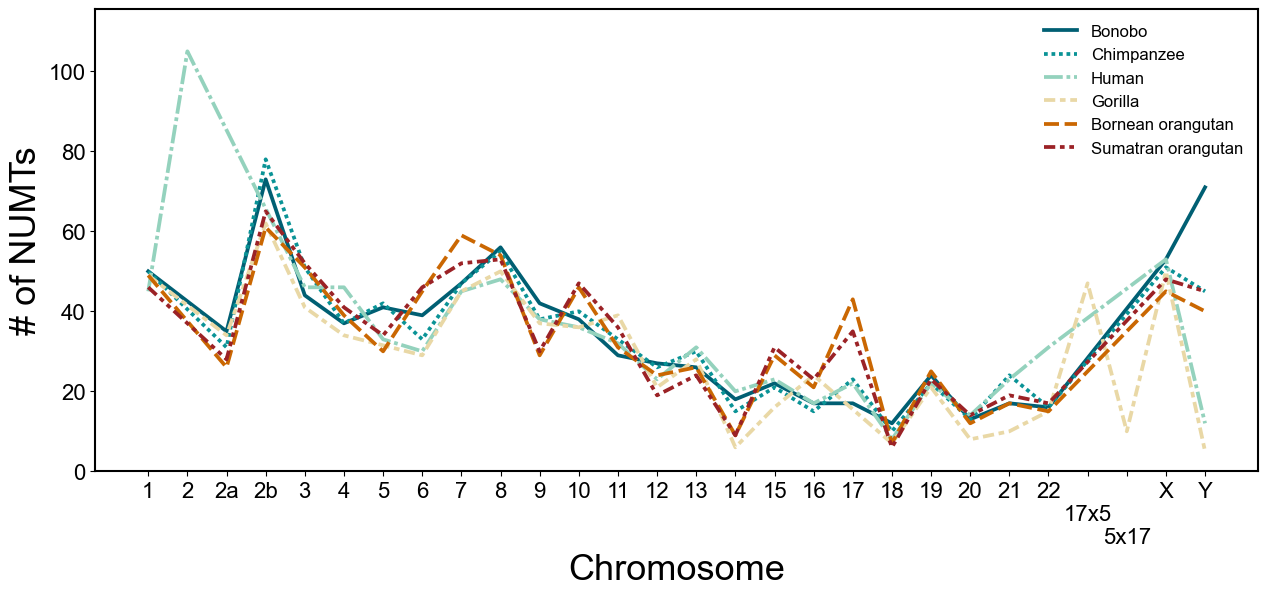

In [12]:
plot_by_chr(numts_summary, y_column='NUMT_Counts', kind='line')

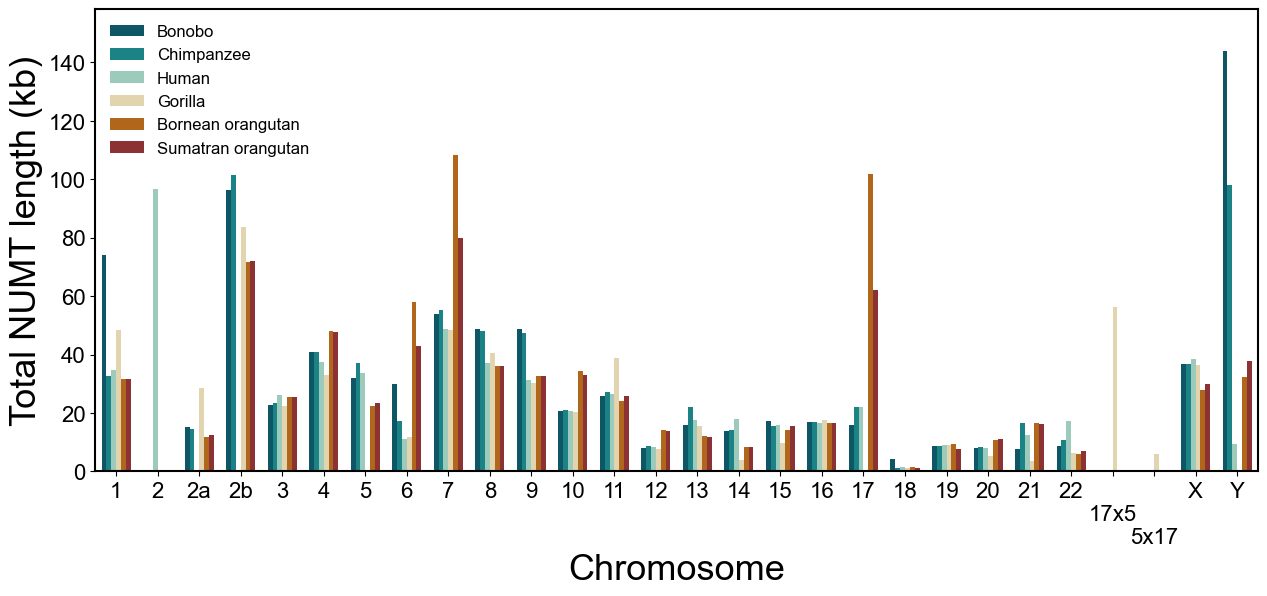

In [13]:
plot_by_chr(numts_summary, y_column='Total_bp', kind='bar')

## Heatmap | NUMT density by species and chromosome

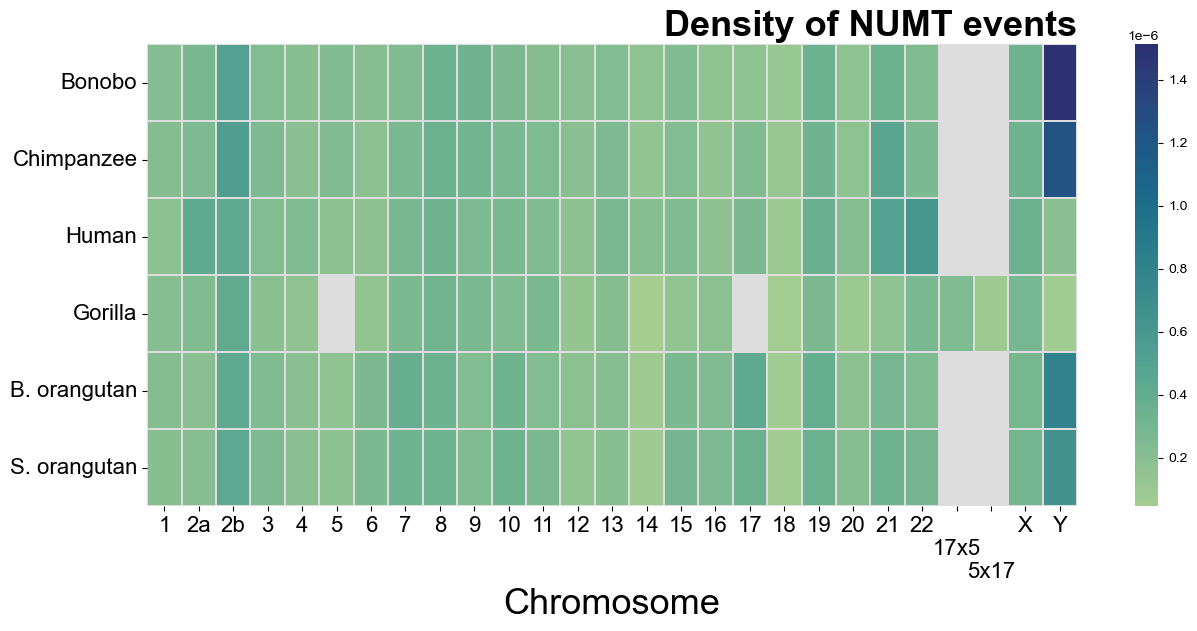

In [14]:

def plot_density_heat(df_in=numts_summary, chrom_column='HSA', data_column='Density_of_events', exclude_y=False, log=False):
    '''
    Heatmap of NUMT density (total_bp/chrom_size) for each species and chromosome.
    Can be changed to visualize NUMT events/bp.
    '''
    df = df_in.copy()
    # Keep T2T assemblies.
    list_assemblies = ['mPanPan1','mPanTro3','CHM13','mGorGor1','mPonAbe1','mPonPyg2']
    df = df[df['Assembly'].isin(list_assemblies)]
    # Rename species.
    df['Species'] = df['Species'].replace({'Sumatran orangutan':'S. orangutan', 'Bornean orangutan':'B. orangutan'})
    # Plot Human chr2 in both 2a and 2b.
    df.loc[ (df['Species']=='Human')&(df[chrom_column]=='2'), chrom_column ] = '2a'
    duplicate_row = df[(df['Species'] == 'Human') & (df[chrom_column] == '2a')].copy() # Select the row that matches the condition
    duplicate_row[chrom_column] = '2b' # Change the chrom_column value to '2b' for the duplicate
    df = pd.concat([df, duplicate_row], ignore_index=True) # Append the duplicate row back to the DataFrame
    # Normalize density using log.
    if log == True:
        df[data_column] = np.log(df[data_column])
    # Turn into 2D matrix.
    df = df[['Species',chrom_column,data_column]].pivot_table(values=data_column,index='Species',columns=chrom_column)
    # Reorder chromosome columns.
    df = df[ ['1','2a','2b'] + [str(x) for x in range(3,23)] + ['17x5','5x17','X','Y'] ]
    df = df.reindex(index=['Bonobo','Chimpanzee','Human','Gorilla','B. orangutan','S. orangutan'])
    # Change 17x5 and 5x17 labels to be lower in the plot.
    df = df.rename(columns={'17x5':'\n17x5','5x17':'\n\n5x17'})
    # Exclude Y chr.
    if exclude_y == True:
        print("# Excluding Y chr.")
        df = df.drop('Y',axis=1)
    # Seaborn parameters.
    cmap = plt.get_cmap('crest')
    cmap.set_bad('#DDD')
    rcParams['figure.figsize'] = 15,6
    #########
    # Plot.
    sns.heatmap( df, cmap=cmap, linecolor='#DDD', linewidths=0.01 ) #'viridis'
    plt.xlabel('Chromosome')
    plt.ylabel('') #plt.ylabel('Species')
    if data_column == 'Density_of_events':
        title = 'Density of NUMT events'
    elif data_column == 'Density_of_bp':
        title = 'Density of total NUMT bp'
    else:
        title = data_column
    # Increase text sizes
    plt.xlabel('Chromosome', fontsize=26)  # X-axis label
    plt.xticks(fontsize=16, rotation=0)   # X-axis tick labels
    plt.yticks(fontsize=16)
    plt.title(title, loc='right', weight='bold', fontsize=26)
    # Export.
    #plt.savefig(f"plots/heatmap_byCHR_{column}.svg") 


plot_density_heat(data_column='Density_of_events', log=False)


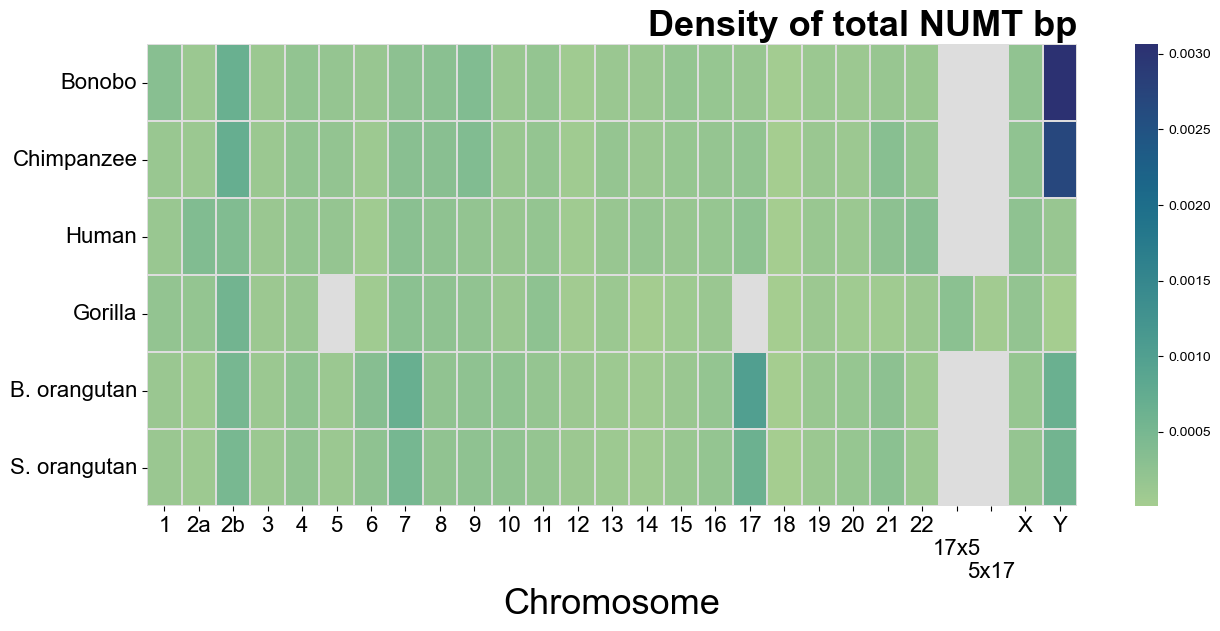

In [15]:
plot_density_heat(data_column='Density_of_bp', log=False)

## Histogram of NUMT lengths

/var/folders/fq/63_fsbc110s_4lv0n6kgz4900000gn/T/ipykernel_75666/4261561576.py:19: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  ax = sns.histplot(


,Species,Median_length
0,B. orangutan,256
1,Bonobo,276
2,Chimpanzee,253
3,Gorilla,252
4,Human,261
5,S. orangutan,258
6,Siamang,242


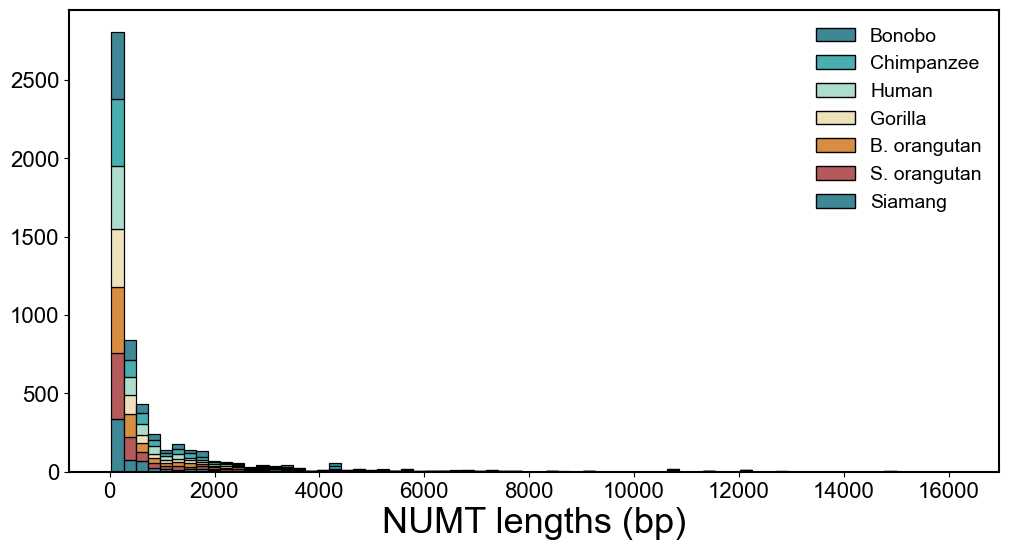

In [22]:
def plot_lengths( df_in=numts, write=False ):
    # Import data.
    #df = pd.read_table(f"../../results/blast_new_01/noStrand.blast.mergedCoords.ALL.tab")
    df = df_in
    #df['NUMT_Length'] = df['End'] - df['Start'] #compute NUMT length
    df = df[['Species','Assembly','Chrom','Start','End','NUMT_Length']] #reorder columns
    df = df.replace({'Sumatran orangutan':'S. orangutan','Bornean orangutan':'B. orangutan'}) #change orangutan names
    # Exclude haplotype assemblies.
    df = df[~df['Assembly'].isin(['mPonPyg2.hap1','mPonPyg2.hap2','mPonAbe1.hap1','mPonAbe1.hap2'])] #exclude some assemblies
    # Annotate and exclude non-T2T assemblies.
    df.loc[(df['Assembly'].str[0]=='m')|(df['Assembly']=='CHM13'), 'Version'] = 'T2T'
    df['Version'] = df.Version.fillna('non-T2T')
    df = df[df['Version']=='T2T']
    # Create a histogram using Seaborn
    palette = [ colorblind_friendly_palette[x] for x in ['Dark blue', 'Light blue', 'Light teal', 'Purple', 'Yellow', 'Vermilion', 'Grey' ] ]
    #palette = ['#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f']
    palette = palette7
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(
        data = df, x = 'NUMT_Length', #log_scale=True,
        hue = 'Species', hue_order = ['Bonobo','Chimpanzee','Human','Gorilla','B. orangutan','S. orangutan','Siamang'],
        bins=70, kde=False, multiple = 'stack',
        color='blue', edgecolor='black', palette = palette,
        )
    # Increase text sizes
    sns.move_legend(ax, fontsize=14, edgecolor='white', loc='best', title='')
    plt.xlabel('NUMT lengths (bp)', fontsize=26)  # X-axis label
    plt.ylabel ( '' , fontsize=26)    # Y-axis label
    plt.xticks(fontsize=16)   # X-axis tick labels
    plt.yticks(fontsize=16)
    if write:
        # Export.
        plt.savefig(f"plots/histplot_numt_lengths.svg")
    # Median NUMT lengths for each species.
    medians = df.groupby('Species')['NUMT_Length'].median().astype('int').reset_index(name='Median_length')
    return medians
    

plot_lengths()

## Line-plot | NUMT stats for orangutans by haplotype

In [23]:
def plot_hap_orangs(y_column='Density_of_bp'):
    list_assemblies = ['mPonAbe1.hap1','mPonAbe1.hap2','mPonPyg2.hap1','mPonPyg2.hap2']
    df = df_in[df_in['Assembly'].isin(list_assemblies)]
    df = sort_hsa(df)
    df['Species_Chrom'] = df['Species_Chrom'].str.split('r').str[1]
    # Seaborn parameters.
    rcParams['figure.figsize'] = 15,6
    # Plot.
    if y_column == 'Abundance':
        y_label = 'NUMT events'
    elif y_column == 'Total_bp':
        y_label = 'Total NUMT bp'
    elif y_column == 'Density_of_bp':
        y_label = 'Density of total NUMT bp'
    else:
        y_label = y_column
    sns.lineplot(
        data = df,
        x = 'Species_Chrom',
        y = y_column,
        hue = 'Species'
    )
    plt.xlabel('Chromosome')
    plt.ylabel( y_label )

plot_hap_orangs(y_column='Abundance')

NameError: name 'df_in' is not defined

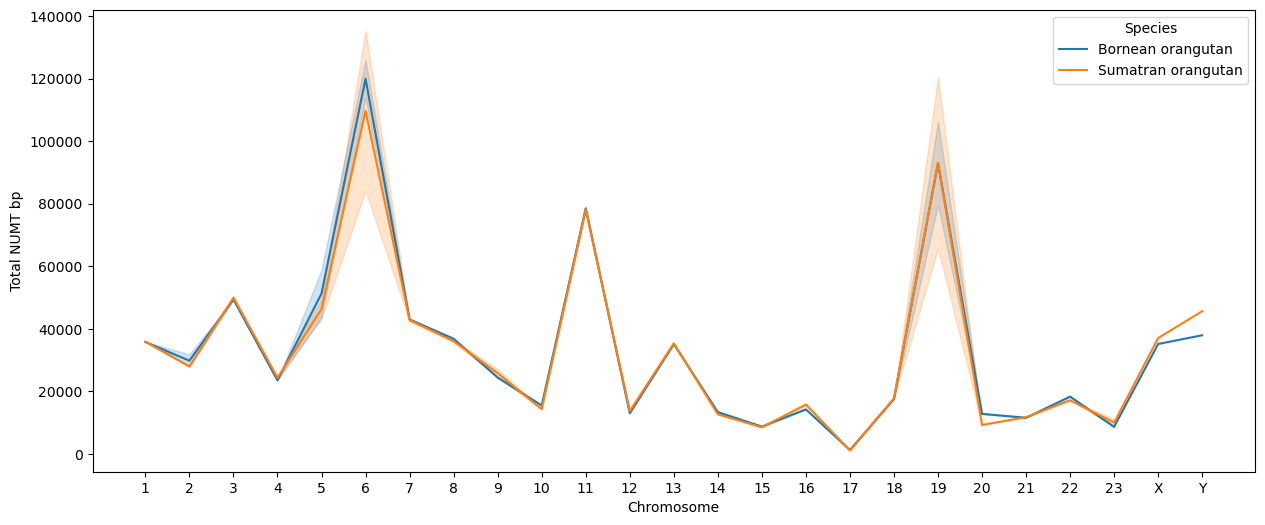

In [ ]:
plot_hap_orangs(y_column='Total_bp')

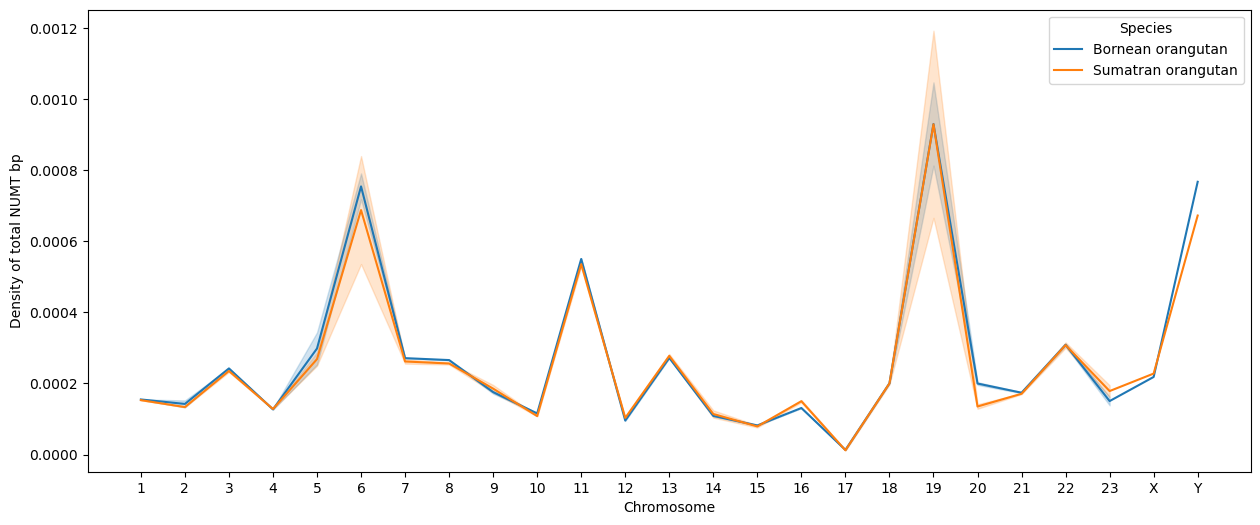

In [ ]:
plot_hap_orangs(y_column='Density_of_bp')

## Bar graph of NUMTs in T2T vs non-T2t assemblies

In [24]:
def plot_bars_nont2t(y_column='Total_bp'):
    subsets = ['autosomes','Xchr','Ychr']
    list_dfs = []
    for subset in subsets:
        df = pd.read_table(f"tables/abundance_Numts_{subset}.table")
        df['Subset'] = subset
        df = df.replace({'Sumatran orangutan':'S. orangutan','Bornean orangutan':'B. orangutan'})
        df = df[~df['Assembly'].isin(['mPonPyg2.hap1','mPonPyg2.hap2','mPonAbe1.hap1','mPonAbe1.hap2'])]
        #return df
        list_dfs = list_dfs + [df]
    df = pd.concat(list_dfs)
    df = df.groupby(['Species','Version'])[y_column].sum().reset_index()
    # Seaborn parameters.
    rcParams['figure.figsize'] = 10,5
    # Plot.
    if y_column == 'Abundance':
        y_label = 'NUMT events'
    elif y_column == 'Density_of_events':
        y_label = 'Density of total NUMT bp'
    elif y_column == 'Total_bp':
        y_label = 'Total NUMT length (kb)'
        # Y axis shortened.
        df[y_column] = df[y_column]/1000
    elif y_column == 'Density_of_bp':
        y_label = 'Density of total NUMT bp'
    else:
        y_label = y_column
    species_order = ['Bonobo','Chimpanzee','Human','Gorilla','S. orangutan','B. orangutan','Siamang']
    barplot = sns.barplot(
        data = df, x = 'Species', y = y_column, hue = 'Version', hue_order = ['non-T2T','T2T'],
        order = species_order, palette=['#7fcdbb','#2c7fb8']
    )
    # Annotate each bar with its height, skipping NaN values
    for p in barplot.patches:
        height = p.get_height()
        if not np.isnan(height):
            barplot.annotate(f'{int(height)}',  # Format height as integer
                                (p.get_x() + p.get_width() / 2., height),
                                ha='center', va='center',
                                xytext=(0, -10),  # 9 points vertical offset
                                textcoords='offset points', fontsize=12, color='white', weight='bold')
    # Add y empty space by adjusting the y-axis limits
    max_value = df[ y_column ].max()
    plt.ylim(0, max_value + max_value * 0.25)  # Add 10% space above the max value
    # Increase text sizes
    plt.legend(loc='upper right', fontsize=14, edgecolor='white')
    plt.xlabel('Genome', fontsize=20)  # X-axis label
    plt.ylabel (y_label , fontsize=20)    # Y-axis label
    plt.xticks(fontsize=14, rotation=15)     # X-axis tick labels
    plt.yticks(fontsize=14)             # Y-axis tick labels
    # Export.
    plt.savefig(f"plots/barplot_vsnont2t_{y_column}.svg")

    return df
    
#%tb
plot_bars_nont2t(y_column='Abundance')

FileNotFoundError: [Errno 2] No such file or directory: 'tables/abundance_Numts_autosomes.table'

,Species,Version,Total_bp
0,B. orangutan,T2T,841.057
1,Bonobo,T2T,876.111
2,Bonobo,non-T2T,613.346
3,Chimpanzee,T2T,799.631
4,Chimpanzee,non-T2T,711.238
5,Gorilla,T2T,636.258
6,Gorilla,non-T2T,594.594
7,Human,T2T,648.314
8,Human,non-T2T,608.308
9,S. orangutan,T2T,767.067


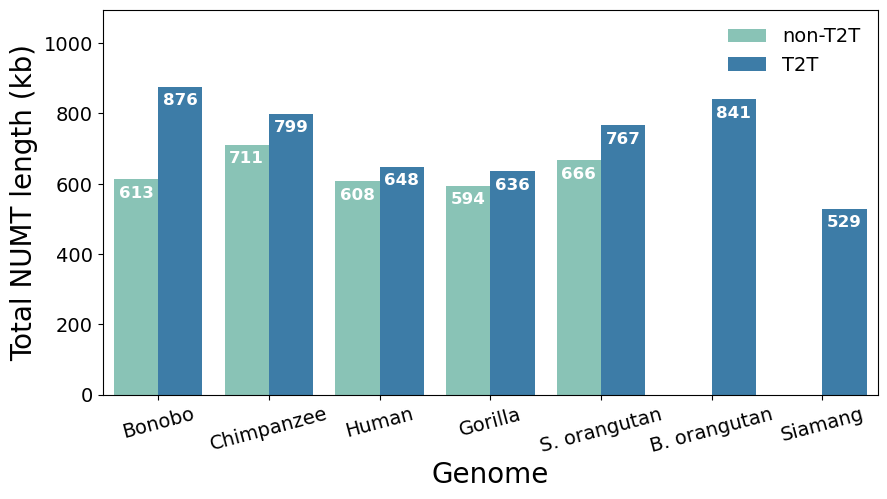

In [ ]:
plot_bars_nont2t(y_column='Total_bp')